# Machine Production Uncertainty

This notebook should visualize the uncertainty of the machine production that is modeled as a gamma distribution:



In [2]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(ROOT / 'src'))

from sda_example_simple.evaluation import HierarchicalEvaluator
from sda_example_simple.models import CostConfig, HierarchicalProductionModel, ProductionConfig
from sda_example_simple.policies import (
    CFALookaheadPolicy, CFAPolicy, DLAPolicy, PFACapacityPolicy, PFAPolicy,
)
from sda_example_simple.simulator import HierarchicalSimulator
from sda_example_simple.tuning import PolicyTuner


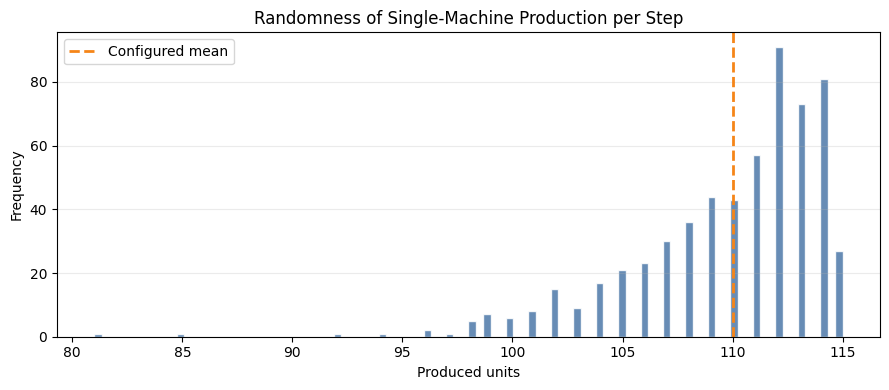

In [18]:
production_config = ProductionConfig(
    total_machines=50,
    steps_per_day=24,
    mean_output_per_machine=110.0,
    max_output_per_machine=115.0,
    beta_shape_a=30.0,
)
cost_config = CostConfig(shortage_cost=60.0, holding_cost=1.2, machine_cost=0.15)

model = HierarchicalProductionModel(production_config, cost_config=cost_config)
simulator = HierarchicalSimulator(model=model)
evaluator = HierarchicalEvaluator(simulator=simulator)

evaluator.plot_machine_randomness(model=model, samples=600, seed=42)


### Machine Uncertainty

Each machine $i$ at each step draws an independent performance factor:

$$
\phi_i \sim \mathrm{Beta}(a,\; b), \quad \phi_i \in [0, 1]
$$

where $b$ is derived with $\mu = \frac{\text{mean-output}}{\text{max-output}}$

$$
b = a \cdot \left(\frac{1-\mu}{\mu} \right)
$$

The realized output of machine $i$ is:

$$
q_i = \mathrm{round}\!\left(\phi_i \cdot \bar{q}\right)
$$

With the current parameterization ($\mu$ ~ 0.9), $b < a$, so the distribution is skewed toward high output; at the same time, it retains a meaningful left tail (a "fat tail" for underperformance) that captures occasional weak machine steps.